In [3]:
import pandas as pd
import os
import cv2
import random
from pandas import read_excel
from pandas import DataFrame
from sklearn.decomposition import PCA
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import pickle
import matplotlib.pyplot as plt
from functions import *

Train data

In [4]:
file_name = 'data_train_augm_Pb.xlsx'
df = read_excel(file_name, sheet_name = 'Relavage Pb')

In [6]:
df

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl1_pb2-4-0.jpg,1.690006,7.865677,13.486435,1.948535
1,rl1_pb2-4-1.jpg,2.099748,7.937776,13.489404,1.984680
2,rl1_pb2-4-10.jpg,1.767706,7.828276,13.729451,2.378208
3,rl1_pb2-4-11.jpg,1.676862,6.941264,13.499201,2.368943
4,rl1_pb2-4-12.jpg,0.753011,8.456981,13.944211,2.178512
...,...,...,...,...,...
1553,rl4_pb8-7-59.jpg,1.141606,10.803873,50.770005,4.112738
1554,rl4_pb8-7-6.jpg,2.230760,11.173671,50.647426,3.818072
1555,rl4_pb8-7-7.jpg,1.074416,11.360265,50.456439,5.145493
1556,rl4_pb8-7-8.jpg,0.576346,10.380542,50.886709,4.582469


In [7]:
fft_features = []
labels_cu = []
labels_pb = []
labels_fe = []
labels_zn = []

In [8]:
for line in df.values:
    image = cv2.imread("../train_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    fft_features.append(fft_pca)
    labels_cu.append(line[1])
    labels_fe.append(line[2])
    labels_pb.append(line[3])
    labels_zn.append(line[4])

In [9]:
fft_features = np.array(fft_features)
labels_cu = np.array(labels_cu)
labels_fe = np.array(labels_fe)
labels_pb = np.array(labels_pb)
labels_zn = np.array(labels_zn)

In [10]:
fft_features.shape

(1558, 400)

In [11]:
labels_cu.shape, labels_fe.shape, labels_pb.shape, labels_zn.shape

((1558,), (1558,), (1558,), (1558,))

In [12]:
labels = np.array([labels_cu, labels_fe, labels_pb, labels_zn]).T

In [13]:
labels.shape

(1558, 4)

SVM with FFT and PCA

In [14]:
svm = SVR()
msvm = MultiOutputRegressor(svm)
msvm.fit(fft_features, labels)

MultiOutputRegressor(estimator=SVR())

Linear Regression with FFT and PCA

In [15]:
lr = LinearRegression()
mlr = MultiOutputRegressor(lr)
mlr.fit(fft_features, labels)

MultiOutputRegressor(estimator=LinearRegression())

XGBoost with FFT and PCA

In [16]:
xgb = XGBRegressor()
mxgb = MultiOutputRegressor(xgb)
mxgb.fit(fft_features, labels)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            predictor=None, random_state=None, ...))

Catboost with FFT and PCA

In [17]:
cbr = cb.CatBoostRegressor()
mcb = MultiOutputRegressor(cbr)
mcb.fit(fft_features, labels, verbose=False)

MultiOutputRegressor(estimator=<catboost.core.CatBoostRegressor object at 0x0000024E9B4940D0>)

Random Forest with FFT and PCA

In [18]:
rf = RandomForestRegressor()
mrf = MultiOutputRegressor(rf)
mrf.fit(fft_features, labels)

MultiOutputRegressor(estimator=RandomForestRegressor())

Gradient Boosting with FFT and PCA

In [19]:
gb = GradientBoostingRegressor()
mgb = MultiOutputRegressor(gb)
mgb.fit(fft_features, labels)

MultiOutputRegressor(estimator=GradientBoostingRegressor())

Ada Boost with FFT and PCA

In [20]:
ada = AdaBoostRegressor()
mada = MultiOutputRegressor(ada)
mada.fit(fft_features, labels)

MultiOutputRegressor(estimator=AdaBoostRegressor())

Decision Trees with FFT and PCA

In [21]:
dt = DecisionTreeRegressor()
mdt = MultiOutputRegressor(dt)
mdt.fit(fft_features, labels)

MultiOutputRegressor(estimator=DecisionTreeRegressor())

KNN with FFT and PCA

In [22]:
knn = KNeighborsRegressor()
mknn = MultiOutputRegressor(knn)
mknn.fit(fft_features, labels)

MultiOutputRegressor(estimator=KNeighborsRegressor())

test data

In [23]:
test_file_name = 'data_test_augm_Pb.xlsx'
df_test = read_excel(test_file_name, sheet_name = 'Relavage Pb')

In [24]:
df_test

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl3_pb2-4-0.jpg,1.804065,4.072680,24.669719,1.967235
1,rl3_pb2-4-1.jpg,1.582374,5.262056,24.650927,2.382289
2,rl3_pb2-4-10.jpg,1.374171,4.200214,24.699497,1.315697
3,rl3_pb2-4-11.jpg,1.999912,4.003937,24.499464,1.782869
4,rl3_pb2-4-12.jpg,1.267787,5.500016,24.639222,1.949993
...,...,...,...,...,...
385,rl4_pb30-6-60.jpg,2.654387,6.100926,58.002102,2.104986
386,rl4_pb30-6-61.jpg,3.419781,6.113207,58.134854,1.998714
387,rl4_pb30-6-7.jpg,3.157589,6.924405,58.004308,1.515859
388,rl4_pb30-6-8.jpg,2.547166,6.429981,57.958764,2.425325


In [25]:
test_fft_features = []
test_labels_cu = []
test_labels_fe = []
test_labels_pb = []
test_labels_zn = []

In [26]:
for line in df_test.values:
    image = cv2.imread("../test_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    test_fft_features.append(fft_pca)
    test_labels_cu.append(line[1])
    test_labels_fe.append(line[2])
    test_labels_pb.append(line[3])
    test_labels_zn.append(line[4])

In [27]:
test_fft_features = np.array(test_fft_features)
test_labels_cu = np.array(test_labels_cu)
test_labels_fe = np.array(test_labels_fe)
test_labels_pb = np.array(test_labels_pb)
test_labels_zn = np.array(test_labels_zn)

In [28]:
test_fft_features.shape

(390, 400)

In [29]:
test_labels_cu.shape, test_labels_fe.shape, test_labels_pb.shape, test_labels_zn.shape

((390,), (390,), (390,), (390,))

In [30]:
test_labels = np.array([test_labels_cu, test_labels_fe, test_labels_pb, test_labels_zn]).T

In [31]:
test_labels.shape

(390, 4)

SVM

In [32]:
y_pred = msvm.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.463640807939264
MSE 68.90836108299843
R2 Score 0.026059178046962006


In [33]:
pickle.dump(msvm, open("./models/svm_model", 'wb'))

XGBoost

In [34]:
y_pred = mxgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.598517026280263
MSE 53.843897637450354
R2 Score 0.11093817418337029


In [35]:
pickle.dump(mxgb, open("./models/xgboost_model", 'wb'))

Linear Regression

In [36]:
y_pred = mlr.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.864510204236619
MSE 61.11574185465926
R2 Score 0.04165165032968063


In [37]:
pickle.dump(mlr, open("./models/linear_regression_model", 'wb'))

Catboost

In [38]:
y_pred = mcb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.443144494291603
MSE 48.84082407061502
R2 Score 0.16856410840552472


In [39]:
pickle.dump(mcb, open("./models/catboost_model", 'wb'))

Random Forest

In [40]:
y_pred = mrf.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.438118688011894
MSE 45.90416030566507
R2 Score 0.17848666782046765


In [41]:
pickle.dump(mrf, open("./models/random_forest_model", 'wb'))

Grandient Boosting

In [42]:
y_pred = mgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.555298813272863
MSE 50.94477975803227
R2 Score 0.16118295174846217


In [43]:
pickle.dump(mgb, open("./models/gradient_boosting_model", 'wb'))

Ada Boosting

In [44]:
y_pred = mada.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.818813335628876
MSE 52.658427285303866
R2 Score 0.13858342962713668


In [45]:
pickle.dump(mada, open("./models/ada_boosting_model", 'wb'))

Decision Trees

In [46]:
y_pred = mdt.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.725041158881995
MSE 97.65970792837898
R2 Score -0.332370573671767


In [47]:
pickle.dump(mdt, open("./models/decision_tree_model", 'wb'))

KNN

In [48]:
y_pred = mknn.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.164657965695499
MSE 45.35631003618641
R2 Score 0.2040049446805166


In [49]:
pickle.dump(mknn, open("./models/knn_model", 'wb'))

# All test videos average

In [50]:
test_videos = ["rl4_pb12-4.mp4", "rl1_pb16-4.mp4", "rl3_pb23-4.mp4", "rl1_pb9-5.mp4", "rl4_pb30-6.mp4"]
models = [msvm, mrf, mxgb, mcb, mgb, mada, mdt, mknn]

In [51]:
final_results_df = pd.DataFrame(columns=["Model", "Cu", "Fe", "Pb", "Zn"])

In [52]:
for model in models:
    model_name = type(model.estimator).__name__
    avgs_cu, avgs_fe, avgs_pb, avgs_zn = [], [], [], []
    for test_vid in test_videos:
        TeunneurReel = TenneurReel(test_vid, "DataSource.xlsx")
        Teneur_predit = predict_video("../video_test/" + test_vid, model)
        Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
        avgs_cu.append(abs(TeunneurReel[0] - Moyenne[0]))
        avgs_fe.append(abs(TeunneurReel[1] - Moyenne[1]))
        avgs_pb.append(abs(TeunneurReel[2] - Moyenne[2]))
        avgs_zn.append(abs(TeunneurReel[3] - Moyenne[3]))
        print(model_name + " " + test_vid + " done")
    avgs_cu = np.mean(avgs_cu)
    avgs_fe = np.mean(avgs_fe)
    avgs_pb = np.mean(avgs_pb)
    avgs_zn = np.mean(avgs_zn)
    final_results_df = pd.concat([final_results_df, pd.DataFrame({"Model": model_name, "Cu": avgs_cu, "Fe": avgs_fe, "Pb": avgs_pb, "Zn": avgs_zn}, index=[0])], ignore_index=True)

SVR rl4_pb12-4.mp4 done
SVR rl1_pb16-4.mp4 done
SVR rl3_pb23-4.mp4 done
SVR rl1_pb9-5.mp4 done
SVR rl4_pb30-6.mp4 done
RandomForestRegressor rl4_pb12-4.mp4 done
RandomForestRegressor rl1_pb16-4.mp4 done
RandomForestRegressor rl3_pb23-4.mp4 done
RandomForestRegressor rl1_pb9-5.mp4 done
RandomForestRegressor rl4_pb30-6.mp4 done
XGBRegressor rl4_pb12-4.mp4 done
XGBRegressor rl1_pb16-4.mp4 done
XGBRegressor rl3_pb23-4.mp4 done
XGBRegressor rl1_pb9-5.mp4 done
XGBRegressor rl4_pb30-6.mp4 done
CatBoostRegressor rl4_pb12-4.mp4 done
CatBoostRegressor rl1_pb16-4.mp4 done
CatBoostRegressor rl3_pb23-4.mp4 done
CatBoostRegressor rl1_pb9-5.mp4 done
CatBoostRegressor rl4_pb30-6.mp4 done
GradientBoostingRegressor rl4_pb12-4.mp4 done
GradientBoostingRegressor rl1_pb16-4.mp4 done
GradientBoostingRegressor rl3_pb23-4.mp4 done
GradientBoostingRegressor rl1_pb9-5.mp4 done
GradientBoostingRegressor rl4_pb30-6.mp4 done
AdaBoostRegressor rl4_pb12-4.mp4 done
AdaBoostRegressor rl1_pb16-4.mp4 done
AdaBoostRegres

In [53]:
final_results_df

,Model,Cu,Fe,Pb,Zn
0,SVR,0.761703,4.051089,13.424650,1.247570
1,RandomForestRegressor,0.703065,3.343162,9.859950,1.362417
2,XGBRegressor,0.670506,3.051726,9.410473,1.275643
3,CatBoostRegressor,0.705545,3.119973,9.618976,1.252422
4,GradientBoostingRegressor,0.699788,3.207692,9.916966,1.268928
5,AdaBoostRegressor,0.783883,3.883044,10.663769,1.363126
6,DecisionTreeRegressor,0.804857,2.770514,11.717312,1.235738
7,KNeighborsRegressor,0.773450,2.989733,7.683409,1.248601


In [54]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [55]:
nn = Sequential()
nn.add(Dense(400, activation='relu', input_shape=(fft_features.shape[1],)))
nn.add(Dropout(0.2))
nn.add(Dense(200, activation='relu'))
nn.add(Dropout(0.2))
nn.add(Dense(50, activation='relu'))
nn.add(Dense(4, activation='linear'))

opt = Adam(learning_rate=0.0001)
nn.compile(optimizer=opt, metrics=['mae'], loss='mse')

In [56]:
hist = nn.fit(fft_features, labels, epochs=200, batch_size=16, verbose=1)

Epoch 1/200
98/98 [==============================] - 2s 3ms/step - loss: 242.7061 - mae: 10.2117
Epoch 2/200
98/98 [==============================] - 0s 3ms/step - loss: 99.7821 - mae: 6.9496
Epoch 3/200
98/98 [==============================] - 0s 3ms/step - loss: 91.8166 - mae: 6.4387
Epoch 4/200
98/98 [==============================] - 0s 3ms/step - loss: 86.8550 - mae: 6.1280
Epoch 5/200
98/98 [==============================] - 0s 3ms/step - loss: 80.4602 - mae: 5.9128
Epoch 6/200
98/98 [==============================] - 0s 3ms/step - loss: 76.7161 - mae: 5.7258
Epoch 7/200
98/98 [==============================] - 0s 3ms/step - loss: 74.3350 - mae: 5.5961
Epoch 8/200
98/98 [==============================] - 0s 3ms/step - loss: 73.4007 - mae: 5.4719
Epoch 9/200
98/98 [==============================] - 0s 3ms/step - loss: 69.1605 - mae: 5.3535
Epoch 10/200
98/98 [==============================] - 0s 3ms/step - loss: 67.5525 - mae: 5.2563
Epoch 11/200
98/98 [===========================

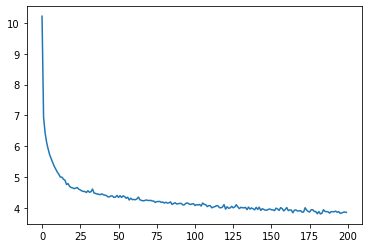

In [57]:
plt.plot(hist.history['mae'])
plt.show()

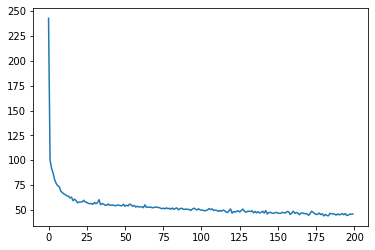

In [58]:
plt.plot(hist.history['loss'])
plt.show()

In [59]:
y_pred = nn.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.826631964527855
MSE 58.49935842515488
R2 Score -0.040337972713393705


In [60]:
model_name = "Neural Network"
avgs_cu, avgs_fe, avgs_pb, avgs_zn = [], [], [], []
for test_vid in test_videos:
    TeunneurReel = TenneurReel(test_vid, "DataSource.xlsx")
    Teneur_predit = predict_video("../video_test/" + test_vid, nn)
    Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
    avgs_cu.append(abs(TeunneurReel[0] - Moyenne[0]))
    avgs_fe.append(abs(TeunneurReel[1] - Moyenne[1]))
    avgs_pb.append(abs(TeunneurReel[2] - Moyenne[2]))
    avgs_zn.append(abs(TeunneurReel[3] - Moyenne[3]))
    print(model_name + " " + test_vid + " done")
avgs_cu = np.mean(avgs_cu)
avgs_fe = np.mean(avgs_fe)
avgs_pb = np.mean(avgs_pb)
avgs_zn = np.mean(avgs_zn)
t = pd.concat([final_results_df, pd.DataFrame({"Model": model_name, "Cu": avgs_cu, "Fe": avgs_fe, "Pb": avgs_pb, "Zn": avgs_zn}, index=[0])], ignore_index=True)

Neural Network rl4_pb12-4.mp4 done
Neural Network rl1_pb16-4.mp4 done
Neural Network rl3_pb23-4.mp4 done
Neural Network rl1_pb9-5.mp4 done
Neural Network rl4_pb30-6.mp4 done


In [61]:
t

,Model,Cu,Fe,Pb,Zn
0,SVR,0.761703,4.051089,13.424650,1.247570
1,RandomForestRegressor,0.703065,3.343162,9.859950,1.362417
2,XGBRegressor,0.670506,3.051726,9.410473,1.275643
3,CatBoostRegressor,0.705545,3.119973,9.618976,1.252422
4,GradientBoostingRegressor,0.699788,3.207692,9.916966,1.268928
5,AdaBoostRegressor,0.783883,3.883044,10.663769,1.363126
6,DecisionTreeRegressor,0.804857,2.770514,11.717312,1.235738
7,KNeighborsRegressor,0.773450,2.989733,7.683409,1.248601
8,Neural Network,0.827539,3.227606,10.187055,1.634861


In [64]:
mae_mse_df = pd.DataFrame(columns=["Model", "MAE", "MSE"])
for model in models:
    model_name = type(model.estimator).__name__
    y_pred = model.predict(test_fft_features)
    mae_mse_df = pd.concat([mae_mse_df, pd.DataFrame({"Model": model_name, "MAE": mean_absolute_error(test_labels, y_pred), "MSE": mean_squared_error(test_labels, y_pred)}, index=[0])], ignore_index=True)

In [65]:
mae_mse_df

,Model,MAE,MSE
0,SVR,5.463641,68.908361
1,RandomForestRegressor,4.438119,45.904160
2,XGBRegressor,4.598517,53.843898
3,CatBoostRegressor,4.443144,48.840824
4,GradientBoostingRegressor,4.555299,50.944780
5,AdaBoostRegressor,4.818813,52.658427
6,DecisionTreeRegressor,5.725041,97.659708
7,KNeighborsRegressor,4.164658,45.356310


In [66]:
model_name = "Neural Network"
y_pred = nn.predict(test_fft_features)
mae_mse_df = pd.concat([mae_mse_df, pd.DataFrame({"Model": model_name, "MAE": mean_absolute_error(test_labels, y_pred), "MSE": mean_squared_error(test_labels, y_pred)}, index=[0])], ignore_index=True)

In [67]:
mae_mse_df

,Model,MAE,MSE
0,SVR,5.463641,68.908361
1,RandomForestRegressor,4.438119,45.904160
2,XGBRegressor,4.598517,53.843898
3,CatBoostRegressor,4.443144,48.840824
4,GradientBoostingRegressor,4.555299,50.944780
5,AdaBoostRegressor,4.818813,52.658427
6,DecisionTreeRegressor,5.725041,97.659708
7,KNeighborsRegressor,4.164658,45.356310
8,Neural Network,4.826632,58.499358


In [69]:
# join t and mae_mse_df
final_results_df = pd.merge(t, mae_mse_df, on="Model")
final_results_df

,Model,Cu,Fe,Pb,Zn,MAE,MSE
0,SVR,0.761703,4.051089,13.424650,1.247570,5.463641,68.908361
1,RandomForestRegressor,0.703065,3.343162,9.859950,1.362417,4.438119,45.904160
2,XGBRegressor,0.670506,3.051726,9.410473,1.275643,4.598517,53.843898
3,CatBoostRegressor,0.705545,3.119973,9.618976,1.252422,4.443144,48.840824
4,GradientBoostingRegressor,0.699788,3.207692,9.916966,1.268928,4.555299,50.944780
5,AdaBoostRegressor,0.783883,3.883044,10.663769,1.363126,4.818813,52.658427
6,DecisionTreeRegressor,0.804857,2.770514,11.717312,1.235738,5.725041,97.659708
7,KNeighborsRegressor,0.773450,2.989733,7.683409,1.248601,4.164658,45.356310
8,Neural Network,0.827539,3.227606,10.187055,1.634861,4.826632,58.499358


In [71]:
final_results_df.to_excel("final_results_pca1.xlsx", index=False)